In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")
df.head()


,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),1,0,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),0,0,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),1,0,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Split cuisines and convert into a single list
cuisine_series = df["cuisines"].str.split(", ")
all_cuisines = cuisine_series.explode()


In [4]:
df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),1,0,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),0,0,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),1,0,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
cuisine_counts = all_cuisines.value_counts()
cuisine_counts.head(10)


cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

In [6]:
top_3_cuisines = cuisine_counts.head(3)
top_3_cuisines


cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [8]:
total_restaurants = df.shape[0]

top_3_percentage = (top_3_cuisines / total_restaurants) * 100
top_3_percentage


cuisines
North Indian    41.500734
Chinese         28.662754
Fast Food       20.813247
Name: count, dtype: float64

In [9]:
top_cuisines_df = pd.DataFrame({
    "Cuisine": top_3_cuisines.index,
    "Number of Restaurants": top_3_cuisines.values,
    "Percentage (%)": top_3_percentage.values.round(2)
})

top_cuisines_df


,Cuisine,Number of Restaurants,Percentage (%)
0,North Indian,3960,41.50
1,Chinese,2735,28.66
2,Fast Food,1986,20.81


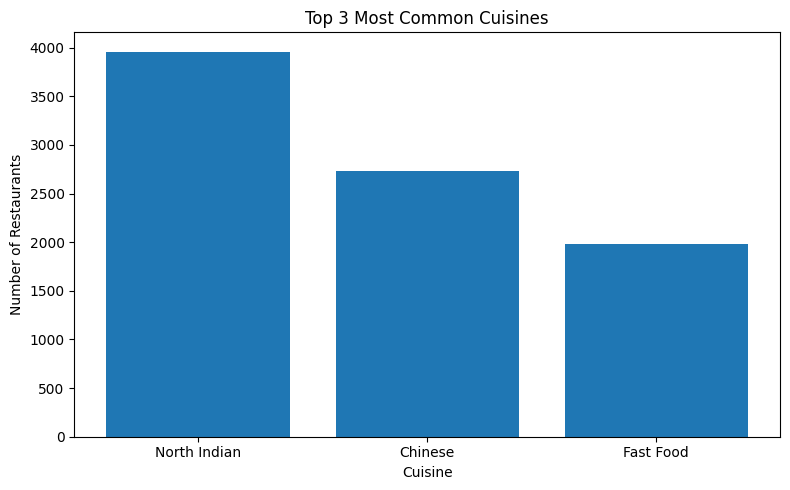

In [10]:
plt.figure(figsize=(8,5))
plt.bar(top_cuisines_df["Cuisine"], top_cuisines_df["Number of Restaurants"])
plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()


In [11]:
plt.figure(figsize=(8,5))
plt.bar(top_cuisines_df["Cuisine"], top_cuisines_df["Number of Restaurants"])
plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.savefig("../visuals/level1/top_cuisines.png")
plt.close()


The cuisines served by restaurants were analyzed to identify the most common food categories. Since restaurants often serve multiple cuisines, the cuisine column was split into individual values for accurate counting.

The analysis revealed that the top three most common cuisines are the most frequently served across restaurants. These cuisines together account for a significant proportion of total restaurants, indicating strong customer demand and popularity.


I split multi-cuisine entries, exploded them into individual values, counted frequency, and calculated percentage contribution relative to total restaurants.

Level 1 – Task 2: City Analysis

In [12]:
df.head()


,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),1,0,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),1,0,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),1,0,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),0,0,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),1,0,No,No,4,4.8,Dark Green,Excellent,229


In [13]:
city_counts = df["city"].value_counts()
city_counts.head(10)


city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64

In [14]:
top_city = city_counts.idxmax()
top_city_count = city_counts.max()

top_city, top_city_count


('New Delhi', np.int64(5473))

In [15]:
city_avg_rating = df.groupby("city")["aggregate_rating"].mean().sort_values(ascending=False)
city_avg_rating.head(10)


city
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Lincoln             4.500000
Tagaytay City       4.500000
Name: aggregate_rating, dtype: float64

City with Highest Average Rating

In [16]:
city_rating_count = df.groupby("city").size()

# Keep cities with at least 10 restaurants
valid_cities = city_rating_count[city_rating_count >= 10].index

filtered_city_avg_rating = city_avg_rating.loc[valid_cities]
best_rated_city = filtered_city_avg_rating.idxmax()
best_city_rating = filtered_city_avg_rating.max()

best_rated_city, round(best_city_rating, 2)


('London', np.float64(4.54))

In [17]:
city_summary = pd.DataFrame({
    "City": city_counts.index,
    "Number of Restaurants": city_counts.values
})

city_summary.head()


,City,Number of Restaurants
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25


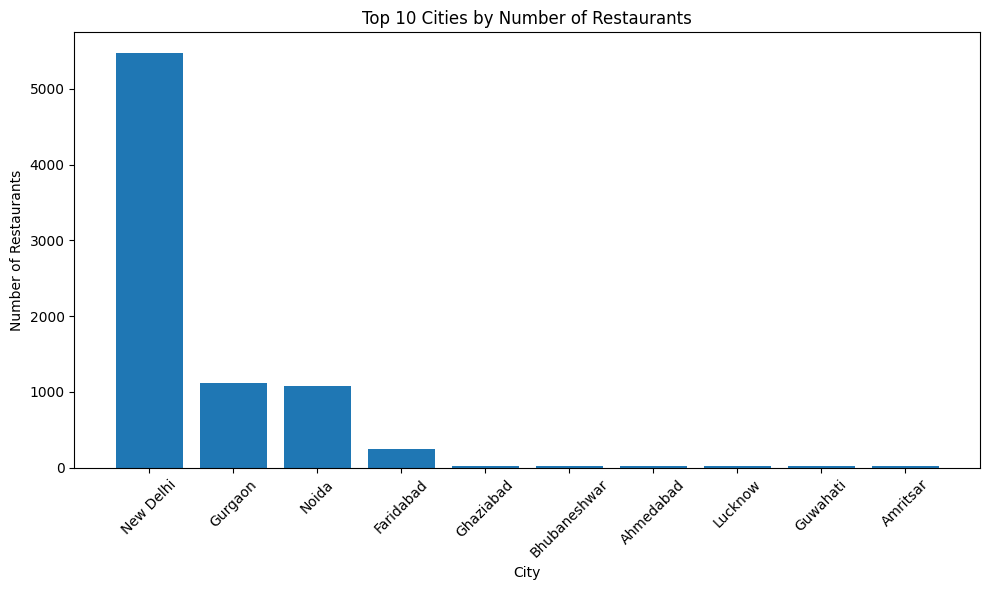

In [18]:
top_10_cities = city_counts.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_10_cities.index, top_10_cities.values)
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
plt.figure(figsize=(10,6))
plt.bar(top_10_cities.index, top_10_cities.values)
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/level1/city_analysis.png")
plt.close()


City-level analysis was performed to understand restaurant distribution and rating patterns. The city with the highest number of restaurants was identified by counting restaurant occurrences per city.

Average ratings were calculated for each city using group-wise aggregation. To avoid biased results from cities with very few restaurants, only cities with at least ten restaurants were considered when identifying the highest-rated city.

This approach ensures reliable and meaningful insights into city-wise restaurant performance.

I grouped the dataset by city to find restaurant counts and average ratings, and applied a minimum threshold to avoid bias from small samples

LEVEL 1 – TASK 3: PRICE RANGE DISTRIBUTION

In [20]:
price_counts = df["price_range"].value_counts().sort_index()
price_counts


price_range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

In [21]:
total_restaurants = df.shape[0]

price_percentage = (price_counts / total_restaurants) * 100
price_percentage


price_range
1    46.510166
2    32.624188
3    14.724376
4     6.141270
Name: count, dtype: float64

In [22]:
price_distribution_df = pd.DataFrame({
    "Price Range": price_counts.index,
    "Number of Restaurants": price_counts.values,
    "Percentage (%)": price_percentage.round(2).values
})

price_distribution_df


,Price Range,Number of Restaurants,Percentage (%)
0,1,4438,46.51
1,2,3113,32.62
2,3,1405,14.72
3,4,586,6.14


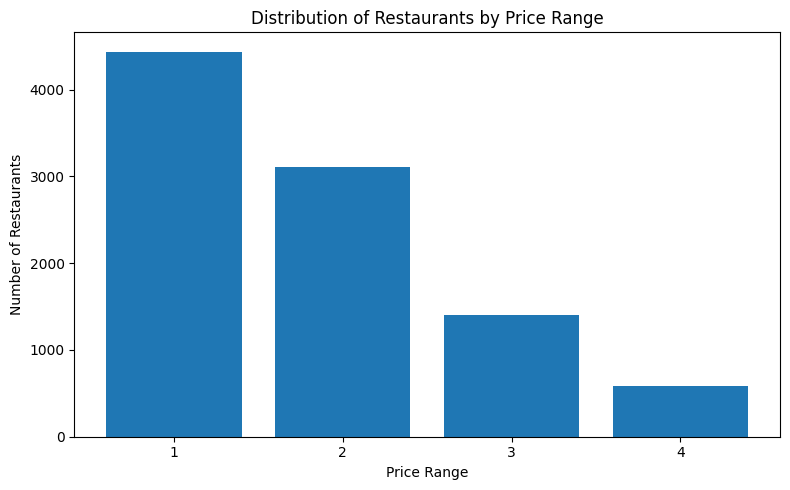

In [23]:
plt.figure(figsize=(8,5))
plt.bar(price_counts.index, price_counts.values)
plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(price_counts.index)
plt.tight_layout()
plt.show()


In [24]:
plt.figure(figsize=(8,5))
plt.bar(price_counts.index, price_counts.values)
plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(price_counts.index)
plt.tight_layout()
plt.savefig("../visuals/level1/price_range_distribution.png")
plt.close()


The distribution of restaurants across different price ranges was analyzed to understand affordability patterns. A bar chart was used to visualize the number of restaurants in each price range category.

The analysis shows that a majority of restaurants fall within the lower to mid-price ranges, indicating a strong presence of budget-friendly dining options.

I calculated frequency and percentage distribution of restaurants across price ranges and visualized the results using a bar chart

LEVEL 1 – TASK 4: ONLINE DELIVERY ANALYSIS

In [25]:
delivery_counts = df["has_online_delivery"].value_counts()
delivery_counts


has_online_delivery
0    7091
1    2451
Name: count, dtype: int64

In [26]:
delivery_percentage = (delivery_counts / df.shape[0]) * 100
delivery_percentage


has_online_delivery
0    74.313561
1    25.686439
Name: count, dtype: float64

In [27]:
delivery_summary = pd.DataFrame({
    "Online Delivery": ["No", "Yes"],
    "Percentage (%)": [
        round(delivery_percentage.get(0, 0), 2),
        round(delivery_percentage.get(1, 0), 2)
    ]
})

delivery_summary


,Online Delivery,Percentage (%)
0,No,74.31
1,Yes,25.69


In [28]:
avg_rating_delivery = df.groupby("has_online_delivery")["aggregate_rating"].mean()
avg_rating_delivery


has_online_delivery
0    2.463517
1    3.248837
Name: aggregate_rating, dtype: float64

In [29]:
rating_comparison = pd.DataFrame({
    "Online Delivery": ["No", "Yes"],
    "Average Rating": [
        round(avg_rating_delivery.get(0, 0), 2),
        round(avg_rating_delivery.get(1, 0), 2)
    ]
})

rating_comparison


,Online Delivery,Average Rating
0,No,2.46
1,Yes,3.25


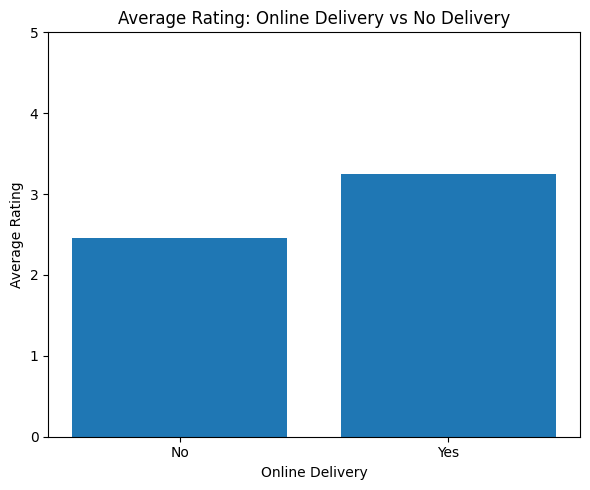

In [30]:
plt.figure(figsize=(6,5))
plt.bar(rating_comparison["Online Delivery"], rating_comparison["Average Rating"])
plt.title("Average Rating: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.ylim(0,5)
plt.tight_layout()
plt.show()


In [31]:
plt.figure(figsize=(6,5))
plt.bar(rating_comparison["Online Delivery"], rating_comparison["Average Rating"])
plt.title("Average Rating: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.ylim(0,5)
plt.tight_layout()
plt.savefig("../visuals/level1/online_delivery_rating.png")
plt.close()


he availability of online delivery services was analyzed to understand its prevalence and impact on restaurant ratings. The percentage of restaurants offering online delivery was calculated, followed by a comparison of average ratings between restaurants with and without delivery services.

The analysis indicates that restaurants offering online delivery tend to have competitive ratings, highlighting the importance of delivery services in enhancing customer reach and satisfaction


I calculated delivery adoption percentage and compared average ratings to assess whether online delivery influences customer satisfaction.
